# Laser Off Code

In [ ]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

# Set Laser and Powermeters Code

In [ ]:
params.laser_set_standard(laser, wavelength=1550e-9, power=7)
params.laser_get_standard(laser)
params.pmeter_set_standard(pmeter=pm100d, wavelength=1550e-9)
params.pmeter_set_standard(pmeter=pms120, wavelength=1550e-9)

# Import

In [49]:
import time
from time import sleep, monotonic
import datetime
import numpy as np
import matplotlib.pyplot as plt
import sys
import pyvisa
import qcodes as qc
from qcodes.dataset import Measurement
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
from qcodes.station import Station
from ipywidgets import interact, IntSlider
initialise_or_create_database_at("./2026-05-11_SNSPD11.db")

import snspd
params = snspd.snspd('snspd11.yaml')

# Set up experiment
exp_name = 'SNSPD11_11_05_2026'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

Experiment loaded. Last ID no: 107


In [82]:
import importlib
importlib.reload(snspd)
params = snspd.snspd('snspd11.yaml')

# Calibration

Text(0.5, 1.0, 'VOA50PM')

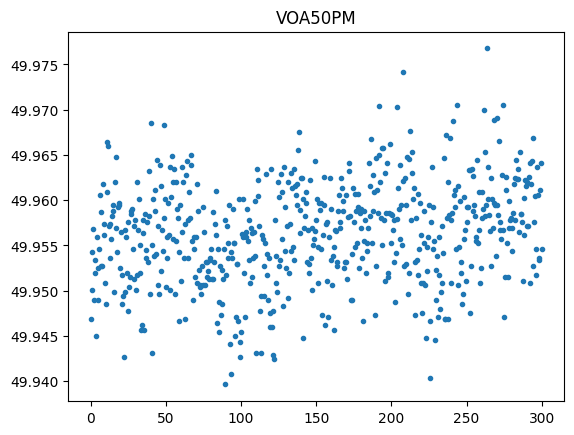

In [42]:
data = load_by_id(params.att_screw_calibration_id).get_parameter_data()
plt.plot(data['times']['times'],data['attenuation']['attenuation'], '.')
plt.title(f'{params.att_screw_name}')

In [43]:
IDs_blue = params.att_blue_calibration_ids
min_id = IDs_blue['start1']
max_id = IDs_blue['stop1']-1

min_id = IDs_blue['start2']
max_id = IDs_blue['start2']

min_id = IDs_blue['start3']
max_id = IDs_blue['stop3']

min_id = IDs_blue['start4']
max_id = IDs_blue['stop4']

def plot_calibration_data(ID):
    data = load_by_id(ID).get_parameter_data()
    plt.plot(data['times']['times'],data['attenuation']['attenuation'], '.')
    plt.title(f'{params.att_blue_name}\nV={data['v_attenuator']['v_attenuator'][0]} V Avg: {params.avg_from_calibration(ID, key='attenuation'):.2f}dB')  
    plt.ylabel('Attenuation (dB)')
    plt.xlabel('Time (s)')
    plt.show()

interact(plot_calibration_data, ID=IntSlider(min=min_id, max=max_id, step=1, value=min_id,
                                  continuous_update=False));



interactive(children=(IntSlider(value=50, continuous_update=False, description='ID', max=68, min=50), Output()…

In [77]:
att_screw = params.avg_from_calibration(params.att_screw_calibration_id, 'attenuation')

ID_blue_calibration = list(np.arange(22, 39)) + [40] + list(np.arange(42, 49)) + list(np.arange(50, 68))

att_blue = [params.avg_from_calibration(ID, 'attenuation') for ID in ID_blue_calibration]
power90_avg = np.average([params.avg_from_calibration(ID, 'power90') for ID in ID_blue_calibration])
v_attenuator_range = [params.avg_from_calibration(ID, 'v_attenuator') for ID in ID_blue_calibration]

db10 = "./2026-04-17_SNSPD10.db"
exname10 = 'SNSPD10'
sampname10 = '00'
ID = 7
attenuation_10 = params.load_id_from_database(db10, exname10, sampname10, ID).get_parameter_data()['attenuation']['attenuation']
still_temp_10 = params.load_id_from_database(db10, exname10, sampname10, ID).get_parameter_data()['still_temp']['still_temp']

fibre_attenuation = attenuation_10[-1]/2 # data taken cooling, last data point (coldest)

total_attenuation = att_screw + att_blue + fibre_attenuation

# Re-instate database 11 
initialise_or_create_database_at("./2026-05-11_SNSPD11.db")

# Set up experiment
exp_name = 'SNSPD11_11_05_2026'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

meas = Measurement()
meas.register_custom_parameter("total_attenuation", label="dB")
meas.register_custom_parameter("v_attenuator", label="V")
meas.register_custom_parameter("power90_avg", label="W")

with meas.run() as datasaver:
    print(datasaver.run_id)
    datasaver.add_result(("total_attenuation", total_attenuation),
                        ("v_attenuator", v_attenuator_range),
                        ("power90_avg", power90_avg))


Experiment loaded. Last ID no: 132
Starting experimental run with id: 133. 
133


In [37]:
Nphotons = params.photon_number(power90=power_90_avg, total_attenuation=att_screw + att_blue + fibre_attenuation, wavelength=1550e-9)

Starting experimental run with id: 83. 
83


([<Axes: title={'center': 'Run #83, Experiment SNSPD11_11_05_2026 (00)'}, xlabel='dB', ylabel='Nphotons'>],
 [None])

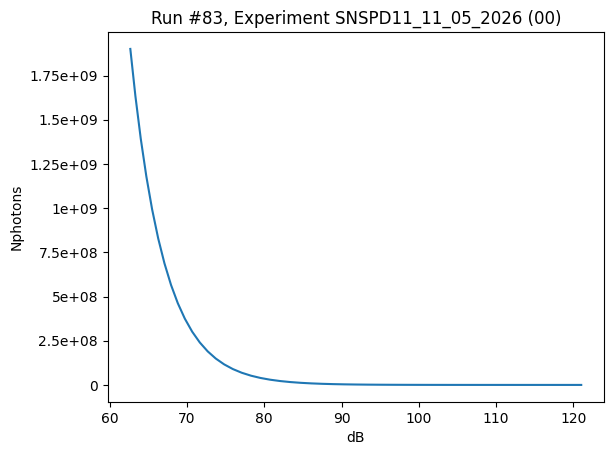

In [38]:
plot_by_id(83)

# Photon number calculation across wavelengths

In [63]:
data = load_by_id(83).get_parameter_data()
data

{'Nphotons': {'Nphotons': array([1.90074794e+09, 1.63340728e+09, 1.39181398e+09, 1.17990623e+09,
         9.93194972e+08, 8.28519053e+08, 6.87763718e+08, 5.65331692e+08,
         4.62219739e+08, 3.74833825e+08, 3.00900145e+08, 2.40234497e+08,
         1.89891971e+08, 1.49239221e+08, 1.16361658e+08, 8.97035973e+07,
         6.87844852e+07, 5.21624943e+07, 3.94094219e+07, 2.95462790e+07,
         2.19141457e+07, 1.62007202e+07, 1.18550291e+07, 8.64929020e+06,
         6.27085844e+06, 4.51093825e+06, 3.22898466e+06, 2.29031767e+06,
         1.61830602e+06, 1.13287352e+06, 7.81332480e+05, 5.35985390e+05,
         3.60471558e+05, 2.39158407e+05, 1.55576822e+05, 9.86806616e+04,
         6.10062846e+04, 3.63869652e+04, 2.11538373e+04, 1.19165906e+04,
         6.63091126e+03, 3.94873099e+03, 2.79948501e+03]),
  'attenuation': array([ 62.68338772,  63.34168812,  64.03682104,  64.75415806,
          65.50228788,  66.289608  ,  67.09824038,  67.94959968,
          68.82414812,  69.73424525,  70.6

In [80]:
IDta = params.total_att_ID
data = load_by_id(IDta).get_parameter_data()
total_attenuation = data['total_attenuation']['total_attenuation']
v_attenuator = data['v_attenuator']['v_attenuator']
idx, _ = params.match(5.5, v_attenuator)

Check match:5.5 (test) = [5.5]?


In [59]:
data

{'total_attenuation': {'total_attenuation': array([ 62.68338772,  63.34168812,  64.03682104,  64.75415806,
          65.50228788,  66.289608  ,  67.09824038,  67.94959968,
          68.82414812,  69.73424525,  70.68840902,  71.66627929,
          72.68756697,  73.73380326,  74.81453399,  75.9445344 ,
          77.09772809,  78.2990495 ,  79.51663235,  80.76760505,
          82.06538755,  83.37728977,  84.73360677,  86.10282831,
          87.49936303,  88.92996418,  90.38197319,  91.87367577,
          93.3820265 ,  94.93081873,  96.54427422,  98.18110348,
          99.90392297, 101.68577648, 103.55318404, 105.53031248,
         107.61888724, 109.86317465, 112.21874141, 114.71111279,
         117.25690084, 119.50805752, 121.00185154]),
  'index': array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
         17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
         34, 35, 36, 37, 38, 39, 40, 41, 42])}}

total_attenuation has saved correctly

In [65]:
l = [float(val) for val in params.laser_wav_range.values()]
laser_wav_range = np.arange(l[0], l[1]+l[2], l[2])

{'start': '1528e-9', 'stop': '1565e-9', 'step': '1e-9'}

In [89]:
IDta = params.total_att_ID
data = load_by_id(IDta).get_parameter_data()
v_attenuator = data['v_attenuator']['v_attenuator']
idx, _ = params.match(5.5, v_attenuator)
ta_5_5_v = data['total_attenuation']['total_attenuation'][idx]

l = [float(val) for val in params.laser_wav_range.values()]
laser_wav_range = np.arange(l[0], l[1]+l[2], l[2])
Nphotons = params.photon_number(power90=power_90_avg, total_attenuation=ta_5_5_v, wavelength=laser_wav_range)

Check match:5.5 (test) = [5.5]?
Starting experimental run with id: 137. 
137


Text(0.5, 0, 'Wavelength (nm)')

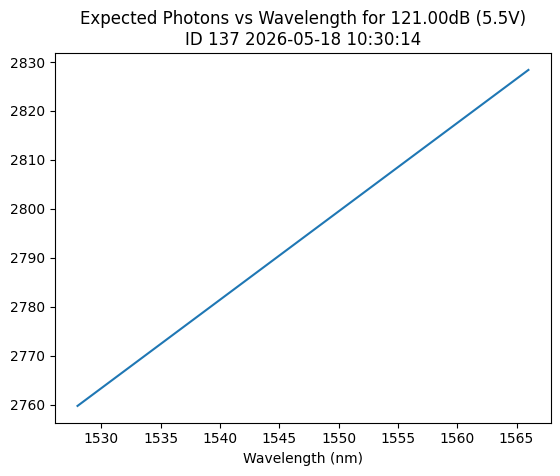

In [95]:
data = load_by_id(137).get_parameter_data()
attenuation = data['attenuation']['attenuation']
Nphotons = data['Nphotons']['Nphotons']
wavelength = data['wavelength']['wavelength']
plt.plot(wavelength*1e9, Nphotons)
plt.title(params.make_title(ID=137, title=f'Expected Photons vs Wavelength for {attenuation[0]:.2f}dB (5.5V)'))
plt.xlabel('Wavelength (nm)')
plt.xlabel('Photons/sec')

In [84]:
IDta = params.total_att_ID
data = load_by_id(IDta).get_parameter_data()
v_attenuator = data['v_attenuator']['v_attenuator']
total_attenuation = data['total_attenuation']['total_attenuation']

l = [float(val) for val in params.laser_wav_range.values()]
laser_wav_range = np.arange(l[0], l[1]+l[2], l[2])
Nphotons = params.photon_number(power90=power_90_avg, total_attenuation=total_attenuation, wavelength=laser_wav_range)

Starting experimental run with id: 136. 
136


In [87]:
data = load_by_id(136).get_parameter_data()
data

{'attenuation': {'attenuation': array([ 62.68338772,  63.34168812,  64.03682104, ..., 117.25690084,
         119.50805752, 121.00185154], shape=(1677,)),
  'index': array([   0,    1,    2, ..., 1674, 1675, 1676], shape=(1677,))},
 'Nphotons': {'Nphotons': array([1.87376958e+09, 1.61022344e+09, 1.37205920e+09, ...,
         6.69935938e+03, 3.98949209e+03, 2.82838292e+03], shape=(1677,)),
  'index': array([   0,    1,    2, ..., 1674, 1675, 1676], shape=(1677,))},
 'wavelength': {'wavelength': array([1.528e-06, 1.529e-06, 1.530e-06, ...,       nan,       nan,
               nan], shape=(1677,)),
  'index': array([   0,    1,    2, ..., 1674, 1675, 1676], shape=(1677,))}}

# Fibre Attenuation from Cooldown 10

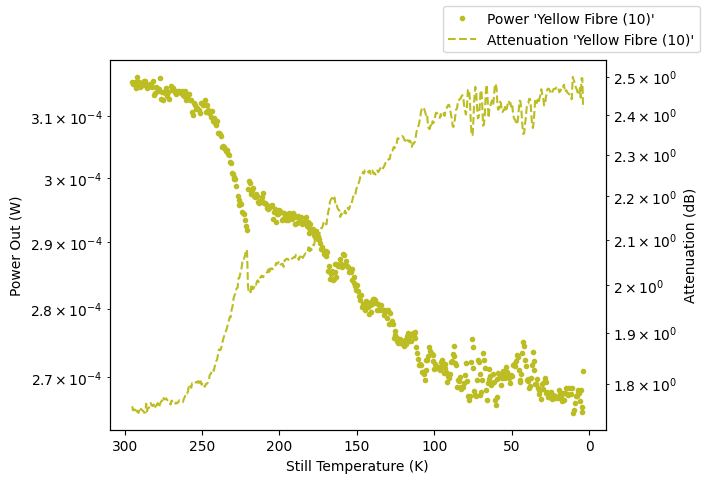

In [156]:
db10 = "./2026-04-17_SNSPD10.db"
exname10 = 'SNSPD10'
sampname10 = '00'
ID = 7
data_10 = params.load_id_from_database(db10, exname10, sampname10, ID).get_parameter_data()
power10_10 = data_10['power10']['power10']
power90_10 = data_10['power90']['power90']
attenuation_10 = data_10['attenuation']['attenuation']
still_temp_10 = data_10['still_temp']['still_temp']

fig, ax1 = plt.subplots()

ax2 = ax1.twinx()

ax1.semilogy(still_temp_10, power10_10, '.', color = 'tab:olive', label='Power \'Yellow Fibre (10)\'')
ax1.set_xlabel('Still Temperature (K)')
ax1.set_ylabel('Power Out (W)')
ax1.invert_xaxis()

ax2.semilogy(still_temp_10, attenuation_10, '--', color='tab:olive', label='Attenuation \'Yellow Fibre (10)\'') 
ax2.set_xlabel('Still Temperature (K)')
ax2.set_ylabel('Attenuation (dB)')

fig.legend()
